# Plot Joined Percentile Analysis

This creates a time series plots for the evolution of the median in different segments.

Using levante python kernel "1 Python 3" (can be recreated from `../environment-standard.yml`)

In [1]:
import os, sys, glob
import xarray as xr
import numpy as np
import datetime

import pylab as plt
import seaborn as sns
sns.set_context('talk')

## Input

In [2]:
base_path = '/work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics'
filelist = sorted( glob.glob(f'{base_path}/joined*nc') )

In [3]:
for i, fname in enumerate( filelist ):
    print(i, fname )

0 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width100km_reinit12h.nc
1 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width100km_reinit24h.nc
2 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width200km_reinit12h.nc
3 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width200km_reinit24h.nc
4 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width300km_reinit24h_single.nc
5 /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width400km_reinit24h_single.nc


In [4]:
if 'launcher' in sys.argv[0]:
    iexp = 2
else:
    iexp = int( sys.argv[1] )

In [5]:
fname = filelist[iexp]

print(f'...open {fname}')
d = xr.open_dataset(fname)

...open /work/bb1376/data/icon/atlantic-cases/derived-data/segment-statistics/joined_percentiles-in-circle_hurricane-centric_paulette2020-width200km_reinit12h.nc


In [6]:
expname = fname.split('-')[-1].replace('.nc','')

In [7]:
d['time'] = d.time  / 12.
d['time'].attrs = {'units':'hours'}

In [8]:
#d_std = (d  - d_offset.mean('time')).sel( quantile = slice(0.1,0.9)) # / d_offset.std('time')
d_std = (d  - d.isel(time=0)).sel( quantile = slice(0.1,0.9)) # / d_offset.std('time')


## Plotting

In [9]:
varnames = ['pres_sfc', 't_2m', 'qv_2m']
varnames += ['tqv_dia', 'tqc_dia', 'tqi_dia']

scale = [1e-2,1,1e3, 1., 1e3, 1e3,]

In [10]:
titles = ['(a) Surface Pressure / hPa',
          '(b) 2m Temperature / K',
          '(c) 2m Specific Humidity / (g kg${}^{-1}$)',
          '(d) Total Column Water Vapor / mm',
          '(e) Liquid Water Path / (g m${}^{-2}$)',
          '(f) Ice Water Path / (g m${}^{-2}$)',]

ylabels = ['PDF / (hPa${}^{-1}$)',
           'PDF / (K${}^{-1}$)',
           'PDF / (kg g${}^{-1}$)',
           'PDF / (mm${}^{-1}$)',
           'PDF / (m${}^{2}$ g${}^{-1}$)',
           'PDF / (m${}^{2}$ g${}^{-1}$)',
          ]           

### Plot Median for Different Segments

In [11]:
# Use color cycle for rainbow colors
color_cycle = plt.cm.Spectral_r(np.linspace(0, 1, len(d_std['segment'])))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_cycle)

In [12]:
leg_labels = []
for seg in d_std.segment.data:
    leg_labels += [str(seg).replace('ment', 'ment '),]

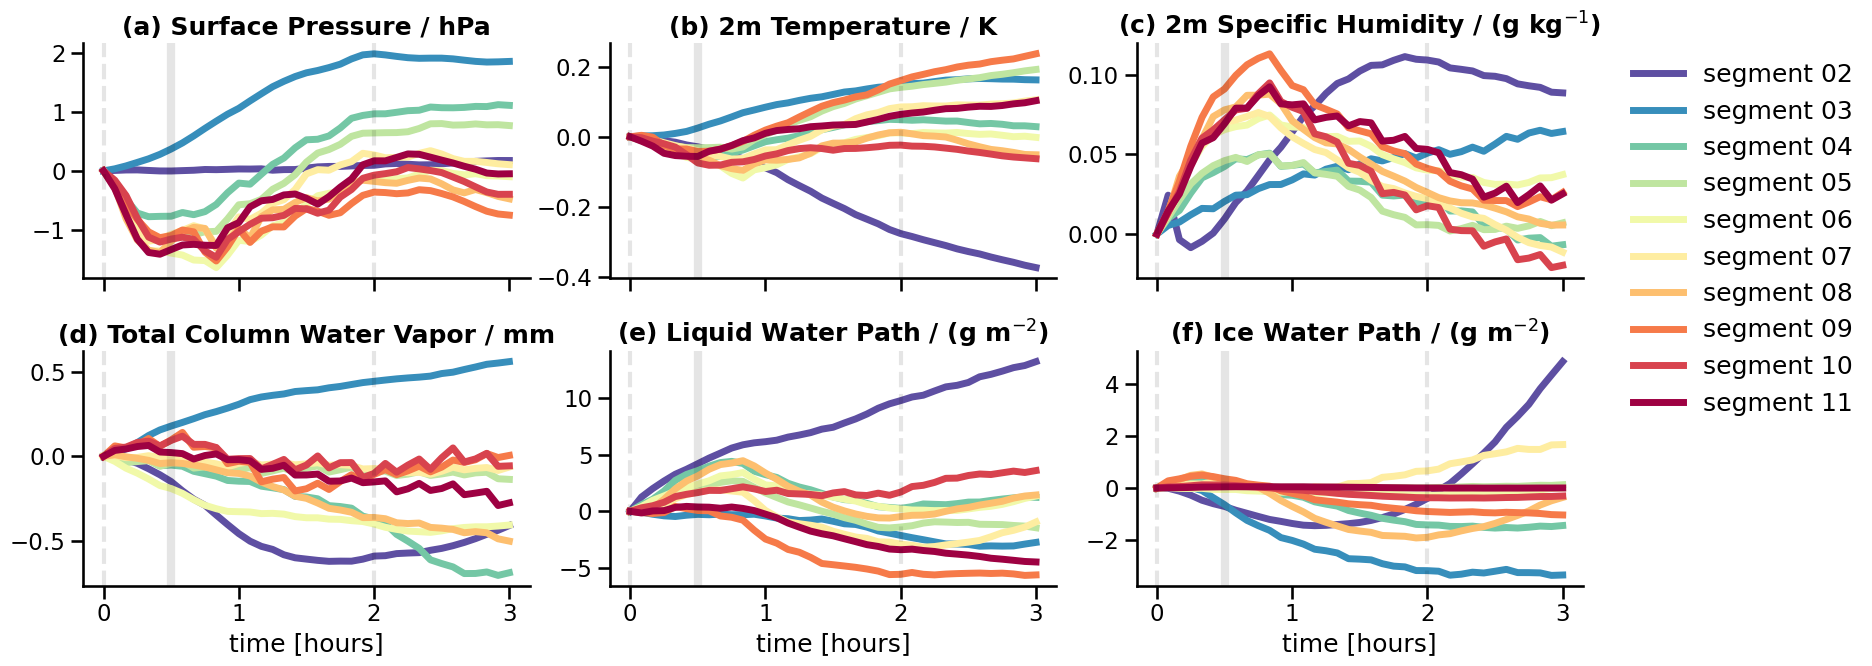

In [13]:
# Create the plot
fig, ax = plt.subplots(figsize=(20, 7), ncols = 3, nrows = 2, sharex = True)
ax = ax.flatten()



for i, vname in enumerate( varnames ):
    if i>23:
        break

    v = scale[i] * d_std[vname].sel(time = slice(0,3), quantile = [0.5,])
    # Plot the data
    plot = v.plot(
        x='time', 
        hue='segment', 
        lw=5, 
        col_wrap=3,
        ax=ax[i],
        add_legend = False
    )
    ax[i].set_title( titles[i], fontweight = 'bold' )
    ax[i].axvline(0, color = 'k', lw = 3, ls ='--', alpha = 0.1)
    ax[i].axvline(0.5, color = 'k', lw = 6, alpha = 0.1)
    ax[i].axvline(2, color = 'k', lw = 3, ls ='--',alpha = 0.1)
    
    ax[i].set_ylabel('')
    if i < 3:
        ax[i].set_xlabel('')
    sns.despine()
plt.tight_layout()

plt.subplots_adjust( right = 0.8)
new_axis = fig.add_axes([0.82, 0.1, 0.1, 0.8])  # [left, bottom, width, height]

labels = leg_labels
new_axis.axis('off')
# Place the legend in the new axis
new_axis.legend(plot, labels, loc='upper left', borderaxespad=0., frameon=False, fontsize = 'medium')
plt.savefig(f'../pics/temporal_evolution_median_{expname}.jpg', dpi = 600)


### Plot Different Percentiles for Fixed Segment

In [14]:
# Use color cycle for rainbow colors
color_cycle = plt.cm.CMRmap_r(np.linspace(0.2, 1, len(d_std['quantile'])))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_cycle)

In [15]:
leg_labels = []
qvec = d_std['quantile'].data

for i, q in enumerate(qvec):
    leg_labels += [ '%.1f' % q ]
    

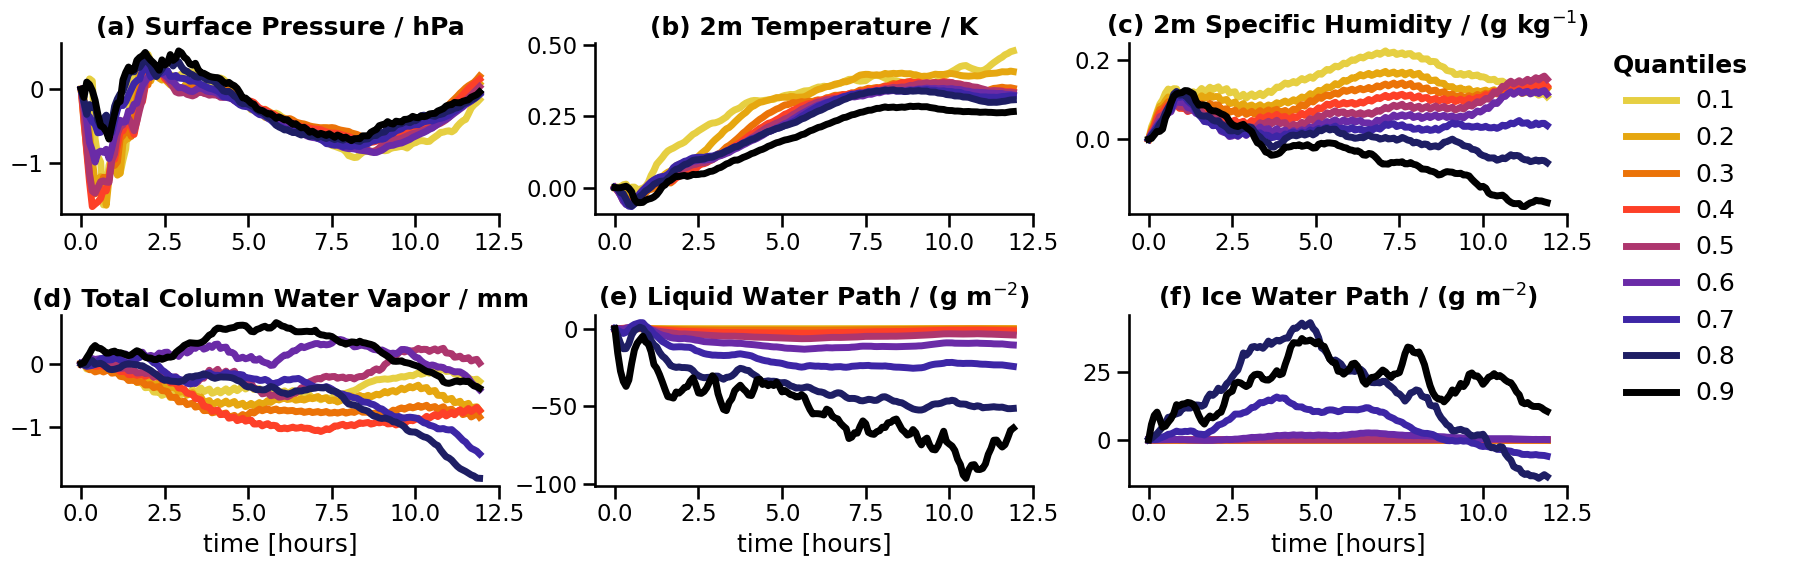

In [16]:
# Create the plot
fig, ax = plt.subplots(figsize=(18, 6), ncols = 3, nrows = 2)
ax = ax.flatten()



for i, vname in enumerate( varnames ): 
    if i>23:
        break
    # Plot the data
    plot = (scale[i]*d_std[vname]).isel(segment=-1).plot(
        x='time', 
        hue='quantile', 
        lw=5, 
        col_wrap=3,
        ax=ax[i],
        add_legend = False
    )
    sns.despine()
    ax[i].set_title( titles[i], fontweight = 'bold' )
    ax[i].set_ylabel('')
    if i < 3:
        ax[i].set_xlabel('')

plt.tight_layout()
plt.subplots_adjust( right = 0.88)
new_axis = fig.add_axes([0.9, 0.1, 0.1, 0.8])  # [left, bottom, width, height]

labels = leg_labels
new_axis.axis('off')
# Place the legend in the new axis
legend = new_axis.legend(plot, labels, loc='upper left', borderaxespad=0., frameon=False, fontsize = 'medium', title='Quantiles')
legend.get_title().set_fontweight('bold')  # Change 'bold' to 'normal', 'light', etc. as needed

plt.savefig(f'../pics/temporal_evolution_lastsegment_{expname}.jpg')
